In [171]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

torch.set_default_device('mps')
x=torch.randn(3,3)
print(x.device)

with open("names.txt", "r") as f:
    names = f.read().splitlines()

# print 5 sample names
names[:5]

mps:0


['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [172]:
# total number of names in dataset
len(names)

32033

In [173]:
# Create data sets (the input n-gram and corresponding expected label)
NGRAM_SIZE = 3 # The n in n-gram

# Map characters to integer indices ('.' is the boundary/padding token)
chars = ['.'] + sorted(set(''.join(names)))
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

X = []
Y = []
for name in names:
    window = "." * NGRAM_SIZE
    for ch in name + ".":
        X.append([stoi[c] for c in window])
        Y.append(stoi[ch])
        #print(f"{window} -> {ch}")
        window = window[1:] + ch

vocab_size = len(chars)

X = torch.tensor(X)
Y = torch.tensor(Y)
X.shape, Y.shape, len(chars)

(torch.Size([228146, 3]), torch.Size([228146]), 27)

In [174]:
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

class Linear:
    def __init__ (self, in_features, out_features, bias=True):
        k = 1/in_features
        upper = k ** 0.5
        lower = -(k ** 0.5)
        self.weight = (upper - lower) * torch.rand((in_features, out_features)) + lower
        self.bias = None if bias is False else torch.zeros((1, out_features))

    def __call__ (self, x): # x is typically of shape (batchsize, in_features)
        """ output is of the shape (batchsize, out_features) """
        self.out = x @ self.weight
        if self.bias is not None:
            self.out = self.out + self.bias
        return self.out

    def parameters (self):
        # Return the leaf tensors themselves. Iterating over self.weight would
        # yield row *views*, which are not leaves, so their .grad stays None.
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm:
    def __init__(self, out_features, eps=1e-05):
        self.eps = eps
        self.gamma = torch.ones((1, out_features))
        self.beta = torch.zeros((1, out_features))

    def __call__(self, x):
        """
        Input shape: (batchsize, featuresize)
        Output shape: (batchsize, featuresize) - same shape as the input
        """
        mean = torch.mean(x, dim=0, keepdim=True) # size = 1, featuresize
        variance = torch.var(x, dim=0, keepdim=True) # size = 1, featuresize
        xhat = (x - mean) / ((variance + self.eps) ** 0.5) # size = batchsize, featuresize
        self.out = (self.gamma * xhat) + self.beta # size = batchsize, featuresize
        return self.out

    def parameters(self):
        params = []
        params.append(self.gamma)
        params.append(self.beta)
        return params


In [175]:
# Training split and validation split (90 - 10)
TRAINING_SPLIT = 0.9
shuffled_indexes = torch.randperm(X.shape[0])

# training set
n_train = int(TRAINING_SPLIT * X.shape[0])
train_indexes = shuffled_indexes[:n_train]
X_train = X[train_indexes]
Y_train = Y[train_indexes]

# validation set
validation_indexes = shuffled_indexes[n_train:]
X_validate = X[validation_indexes]
Y_validate = Y[validation_indexes]


In [176]:
# Instantiate the neural net

torch.manual_seed(100)
EMBEDDING_DIMENSIONS = 2
MINIBATCH_SIZE = 64

with torch.no_grad():
    def eval_loss(Xe, Ye):
        one_hot = F.one_hot(Xe, num_classes=vocab_size).float()
        x = (one_hot @ C).view(-1, EMBEDDING_DIMENSIONS * NGRAM_SIZE)
        for layer in layers:
            x = layer(x)
        return F.cross_entropy(x, Ye).item()

C = torch.randn((vocab_size, EMBEDDING_DIMENSIONS))

# instantiate the net
layers = [
    Linear (EMBEDDING_DIMENSIONS * NGRAM_SIZE, 100, bias=False), 
    BatchNorm(100),
    Tanh(),
    Linear(100, vocab_size)
    ]

parameters = []
for layer in layers:
    for p in layer.parameters():
        parameters.append(p)
parameters.append(C)

for p in parameters:
    p.requires_grad = True

best_val = float('inf')
best_snapshot = None


In [178]:
# training loop
for i in range(200000):

    # construct a batch instead of training on all examples
    batch_indexes = torch.randint(0, X_train.size(0), (MINIBATCH_SIZE,))
    
    # lookup embeddings
    one_hot = F.one_hot(X_train[batch_indexes], num_classes=vocab_size).float() # (32, 3, 27)
    x = one_hot @ C # (32, 3, 2)

    # first linear layer is a layer of 6 neurons
    x = x.view(-1, EMBEDDING_DIMENSIONS * NGRAM_SIZE)

    # call the neural net
    for layer in layers:
        x = layer(x)
    
    # compute loss
    loss = F.cross_entropy(x, Y_train[batch_indexes])

    # compute gradients
    loss.backward()

    # decay the LR as we get better
    if i >= 10000:
        lr = 0.01
    else:
        lr = 0.1

    # adjust weights based on the gradients
    for p in parameters:
        p.data += -lr * p.grad

    # reset gradients to get ready for next pass
    for p in parameters:
        p.grad = None

    # snapshot the best loss and parameters on the validation set
    if i % 1000 == 0:
          vl = eval_loss(X_validate, Y_validate)
          if vl < best_val:
              best_val = vl
              best_snapshot = [p.detach().clone() for p in parameters]
              print(f"{i}: current minibatch loss {loss:.4f} | best validation loss {best_val:.4f}")


9000: current minibatch loss 2.3540 | best validation loss 2.2946
10000: current minibatch loss 2.1558 | best validation loss 2.2901
11000: current minibatch loss 2.3757 | best validation loss 2.2699
12000: current minibatch loss 2.3406 | best validation loss 2.2673
13000: current minibatch loss 2.1764 | best validation loss 2.2668
14000: current minibatch loss 2.1923 | best validation loss 2.2661
15000: current minibatch loss 2.1870 | best validation loss 2.2653
18000: current minibatch loss 2.0991 | best validation loss 2.2647
19000: current minibatch loss 2.3540 | best validation loss 2.2645
20000: current minibatch loss 2.0806 | best validation loss 2.2641
23000: current minibatch loss 2.1616 | best validation loss 2.2624
25000: current minibatch loss 2.3892 | best validation loss 2.2621
28000: current minibatch loss 2.4336 | best validation loss 2.2620
30000: current minibatch loss 2.3719 | best validation loss 2.2614
33000: current minibatch loss 2.2258 | best validation loss 2.2

199999 saturated: 26.6%


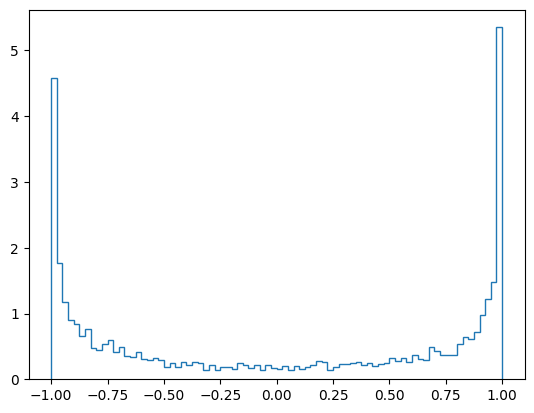

In [165]:
# DIAGNOSTICS

#collect diags using a forward pass. make sure gradients are untouched
with torch.no_grad():
    batch_indexes = torch.randint(0, X_validate.size(0), (1000,))

    # lookup embeddings
    one_hot = F.one_hot(X_validate[batch_indexes], num_classes=vocab_size).float() # (1000, 3, 27)
    x = one_hot @ C # (1000, 3, 2)

    # first linear layer is a layer of 6 neurons
    x = x.view(-1, 6) # (1000, 6)

    # call the neural net
    for layer in layers:
        x = layer(x)

# plt.figure(figsize=(12, 4))
# legends = []
# for i, layer in enumerate(layers):
#     t = layer.out.detach()
#     plt.hist(t.view(-1).tolist(), bins=80, histtype='step', density=True)
#     legends.append(f"{i}: {layer.__class__.__name__}")
# plt.legend(legends)
# plt.title("activation distribution")
# plt.show()

plt.hist(layers[2].out.view(-1).tolist(), bins=80, histtype='step', density=True)
print(f"{i} saturated: {(layers[2].out.abs() > 0.97).float().mean()*100:.1f}%")

In [88]:
# sample the neural net to get name sounding things ...

# g = torch.Generator().manual_seed(2147483647)
# for _ in range(20):
#     out = []
#     context = [0] * 3
#     context = torch.tensor(context)
#     while True:
#         one_hot = F.one_hot(context, num_classes=27).float()
#         embedding = one_hot @ C
#         tanh_activations = torch.tanh(embedding.view(-1, 3*EMBEDDING_DIMENSIONS) @ W1 + b1)
#         logits = tanh_activations @ W2 + b2
#         probs = F.softmax(logits, dim=1)
#         ix = torch.multinomial(probs, num_samples=1, generator=g).item()
#         context = torch.cat([context[1:], torch.tensor([ix])])
#         out.append(ix)
#         if ix == 0:
#             break
#     print(''.join(itos[i] for i in out))